# Subway Challenge route summary statistics

This notebook summarizes the route JSONs in `solutions/` for a blog post. It does not draw route maps; it focuses on aggregate statistics:

1. Overall duration, ranked.
2. Duration split by mode (`train`, `wait`, `transfer`, `run`).
3. Most common start and end stations.
4. Most common start and end times.
5. A few supporting distributions that help explain the search corpus.

Outputs are written to `reports/route_summary/`.

In [1]:
# --- rigter.ink shared figure style -----------------------------------
from pathlib import Path
import importlib
import os
import ssl
import sys
import urllib.request

ROOT = Path.cwd().resolve()
if not (ROOT / "solutions").exists() and (ROOT.parent / "solutions").exists():
    ROOT = ROOT.parent.resolve()
os.chdir(ROOT)

NOTEBOOK_DIR = ROOT / "notebooks"
NOTEBOOK_DIR.mkdir(exist_ok=True)
BLOGSTYLE_URL = "https://raw.githubusercontent.com/fabianrigterink/rigter-ink/main/notebooks/blogstyle.py"
BLOGSTYLE_PATH = NOTEBOOK_DIR / "blogstyle.py"

def refresh_blogstyle():
    try:
        import certifi
        context = ssl.create_default_context(cafile=certifi.where())
    except Exception:
        context = ssl.create_default_context()
    with urllib.request.urlopen(BLOGSTYLE_URL, context=context, timeout=30) as response:
        BLOGSTYLE_PATH.write_bytes(response.read())

try:
    refresh_blogstyle()
except Exception as exc:
    if BLOGSTYLE_PATH.exists():
        print(f"Could not refresh blogstyle.py ({exc}); using local {BLOGSTYLE_PATH}.")
    else:
        raise RuntimeError(
            "Could not download blogstyle.py and no local fallback exists. "
            "Install/update certificates with `python -m pip install --upgrade certifi`, "
            "or on python.org macOS Python run the `Install Certificates.command`, "
            "then rerun this cell."
        ) from exc

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import blogstyle
importlib.reload(blogstyle)
blogstyle.use()
# ----------------------------------------------------------------------

## Configuration

In [2]:
import csv
import json
import math
import pickle
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from subway_challenge.run_layer import RunLayer
from subway_challenge.solver import GRAPH_PKL, hms
from subway_challenge.stations import StationIndex

ROUTE_GLOB = "solutions/*.json"
WORLD_RECORD_S = 22 * 3600 + 14 * 60 + 10
OUT = ROOT / "reports" / "route_summary"
FIGURES = OUT / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

route_files = sorted(ROOT.glob(ROUTE_GLOB))
print(f"Found {len(route_files)} route JSON files.")

Found 9 route JSON files.


## Load graph and station metadata once

This mirrors the validator's transition checks, but caches the graph and run layers so the whole route pool can be summarized efficiently.

In [3]:
with open(GRAPH_PKL, "rb") as f:
    G = pickle.load(f)

station_index = StationIndex.load(ROOT / "data" / "official" / "mta_subway_stations.csv")
canonical = station_index.canonical_stations
node_lookup = {(d["stop"], int(d["t"])): n for n, d in G.nodes(data=True)}
run_layers = {}

def get_runs(radius_m):
    radius_m = int(radius_m or 5000)
    if radius_m not in run_layers:
        run_layers[radius_m] = RunLayer.from_graph(G, radius_m=radius_m)
    return run_layers[radius_m]

def transition(u, v, runs):
    if G.has_edge(u, v):
        edge = G[u][v]
        return edge["weight"], edge.get("mode"), edge
    best = None
    for rv, weight, info in runs.run_successors(u):
        if rv == v and (best is None or weight < best[0]):
            best = (weight, "run", info)
    return best if best is not None else (None, None, None)

def clock_bucket(seconds, minutes=30):
    seconds = int(seconds) % 86400
    bucket = int(round(seconds / (minutes * 60)) * minutes * 60) % 86400
    return f"{bucket // 3600:02d}:{bucket % 3600 // 60:02d}"

def tod(seconds):
    seconds = int(seconds) % 86400
    return f"{seconds // 3600:02d}:{seconds % 3600 // 60:02d}:{seconds % 60:02d}"

def route_family(name):
    if name == "best.json":
        return "incumbent"
    for token, label in [
        ("lns", "LNS"), ("compact", "compact"), ("branch", "branch"),
        ("pattern", "pattern"), ("corridor", "corridor"), ("splice", "splice"),
        ("reorder", "reorder"), ("relocate", "relocate"), ("rotate", "rotation"),
        ("platform", "platform"), ("window", "window"), ("shortcut", "shortcut"),
        ("greedy", "greedy"),
    ]:
        if token in name:
            return label
    return "other"

print(f"Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges; canonical stations={len(canonical)}")

Graph: 1,583,837 nodes, 5,906,115 edges; canonical stations=472


## Score every route

In [4]:
MILESTONES = [100, 250, 400, 425, 450, 472]

def analyze_route(path_json):
    data = json.loads(path_json.read_text())
    raw_path = data.get("path", data)
    meta = data.get("meta", {})
    radius = int(meta.get("radius_m", 5000))
    runs = get_runs(radius)

    nodes = []
    for entry in raw_path:
        stop, t = entry[0], int(entry[1])
        node = node_lookup.get((stop, t))
        if node is None:
            return {"file": path_json.name, "valid": False, "reason": f"missing node {stop}@{t}"}
        nodes.append(node)

    elapsed = 0.0
    mode_counts = Counter()
    mode_seconds = Counter()
    run_meters = 0.0
    run_actual_seconds = 0.0
    illegal = None
    seen = set()
    first_visit_elapsed = []

    for i, node in enumerate(nodes):
        sid = station_index.resolve(G.nodes[node]["stop"])
        if sid in canonical and sid not in seen:
            seen.add(sid)
            first_visit_elapsed.append(int(round(elapsed)))
        if i == len(nodes) - 1:
            break
        w, mode, info = transition(node, nodes[i + 1], runs)
        if w is None:
            a, b = G.nodes[node], G.nodes[nodes[i + 1]]
            illegal = f"illegal {a['stop']}@{int(a['t'])} -> {b['stop']}@{int(b['t'])}"
            break
        elapsed += w
        mode_counts[mode] += 1
        mode_seconds[mode] += w
        if mode == "run" and info:
            run_meters += float(info.get("meters") or 0)
            run_actual_seconds += float(info.get("run_seconds") or 0)

    start_node = nodes[0]
    end_node = nodes[-1]
    start_stop = G.nodes[start_node]["stop"]
    end_stop = G.nodes[end_node]["stop"]
    start_sid = station_index.resolve(start_stop)
    end_sid = station_index.resolve(end_stop)
    start_t = int(G.nodes[start_node]["t"])
    end_t = int(G.nodes[end_node]["t"])
    covered = len(seen & canonical)
    valid = illegal is None and covered == len(canonical)

    rec = {
        "file": path_json.name,
        "path": str(path_json),
        "family": route_family(path_json.name),
        "valid": valid,
        "reason": illegal or "",
        "stations": covered,
        "total_stations": len(canonical),
        "elapsed_s": int(round(elapsed)) if illegal is None else None,
        "elapsed": hms(int(round(elapsed))) if illegal is None else "",
        "delta_record_s": int(round(elapsed - WORLD_RECORD_S)) if illegal is None else None,
        "delta_record": hms(int(round(elapsed - WORLD_RECORD_S)) if elapsed >= WORLD_RECORD_S else int(round(WORLD_RECORD_S - elapsed))) if illegal is None else "",
        "beats_record": bool(illegal is None and valid and elapsed < WORLD_RECORD_S),
        "steps": len(nodes),
        "radius_m": radius,
        "run_km": run_meters / 1000.0,
        "run_actual_s": int(round(run_actual_seconds)),
        "start_stop": start_stop,
        "end_stop": end_stop,
        "start_station_id": start_sid,
        "end_station_id": end_sid,
        "start_station": station_index.station_name.get(start_sid, start_sid),
        "end_station": station_index.station_name.get(end_sid, end_sid),
        "start_t": start_t,
        "end_t": end_t,
        "start_time": tod(start_t),
        "end_time": tod(end_t),
        "start_hour": start_t % 86400 / 3600,
        "end_hour": end_t % 86400 / 3600,
        "start_bucket_30m": clock_bucket(start_t, 30),
        "end_bucket_30m": clock_bucket(end_t, 30),
    }
    for mode in ["train", "wait", "transfer", "run"]:
        rec[f"{mode}_count"] = int(mode_counts[mode])
        rec[f"{mode}_s"] = int(round(mode_seconds[mode]))
        rec[f"{mode}_h"] = mode_seconds[mode] / 3600.0
        rec[f"{mode}_pct"] = (mode_seconds[mode] / elapsed) if elapsed else 0
    for m in MILESTONES:
        rec[f"cover_{m}_s"] = first_visit_elapsed[m - 1] if len(first_visit_elapsed) >= m else None
        rec[f"cover_{m}"] = hms(first_visit_elapsed[m - 1]) if len(first_visit_elapsed) >= m else ""
    return rec

records = []
for i, path_json in enumerate(route_files, start=1):
    if i == 1 or i % 25 == 0 or i == len(route_files):
        print(f"{i:3d}/{len(route_files)} {path_json.name}")
    records.append(analyze_route(path_json))

df = pd.DataFrame(records)
df_valid = df[df["valid"]].sort_values(["elapsed_s", "steps", "file"]).reset_index(drop=True)
df_all = df.sort_values(["valid", "elapsed_s", "file"], ascending=[False, True, True]).reset_index(drop=True)

df_all.to_csv(OUT / "route_summary.csv", index=False)
df_all.to_json(OUT / "route_summary.json", orient="records", indent=2)

print(f"Valid full routes: {len(df_valid):,}/{len(df):,}")
print(f"Best: {df_valid.iloc[0]['file']} at {df_valid.iloc[0]['elapsed']}")
print(f"Wrote {OUT / 'route_summary.csv'}")

  1/9 best.json
OSRM matrix: 424 points, 0 new table calls (cache now 179352 cells).
  9/9 window_replan_fresh_bayridge_pass2_probe.json
Valid full routes: 9/9
Best: best.json at 24:24:30
Wrote /Users/fabianrigterink/Desktop/Code/subway-challenge/reports/route_summary/route_summary.csv


## 1. Overall duration, ranked

In [5]:
leaderboard_cols = [
    "file", "family", "elapsed", "delta_record", "beats_record", "stations", "steps",
    "start_station", "start_time", "end_station", "end_time", "run_km",
]
leaderboard = df_valid[leaderboard_cols].copy()
leaderboard.to_csv(OUT / "leaderboard.csv", index=False)
display(leaderboard.head(30).style.format({"run_km": "{:.1f}"}))

leaderboard_md = "\n".join([
    "| rank | file | elapsed | vs record | start | end | run km |",
    "|---:|---|---:|---:|---|---|---:|",
    *[
        f"| {i+1} | `{row.file}` | {row.elapsed} | {row.delta_record} | {row.start_station} {row.start_time} | {row.end_station} {row.end_time} | {row.run_km:.1f} |"
        for i, row in enumerate(df_valid.head(20).itertuples())
    ],
])
(OUT / "leaderboard.md").write_text(leaderboard_md)
display(Markdown(leaderboard_md))

,file,family,elapsed,delta_record,beats_record,stations,steps,start_station,start_time,end_station,end_time,run_km
0,best.json,incumbent,24:24:30,02:10:20,False,472,652,Inwood-207 St,06:03:00,110 St-Malcolm X Plaza,06:27:30,38.1
1,branch_span_relocate_late_codex.json,branch,24:24:30,02:10:20,False,472,654,Inwood-207 St,06:03:00,110 St-Malcolm X Plaza,06:27:30,36.7
2,platform_start_phase_A02S_morning_codex.json,platform,24:24:30,02:10:20,False,472,654,Inwood-207 St,06:03:00,110 St-Malcolm X Plaza,06:27:30,36.7
3,lns_refine_pruned_donor_codex.json,LNS,24:24:30,02:10:20,False,472,670,Inwood-207 St,06:03:00,110 St-Malcolm X Plaza,06:27:30,29.1
4,lns_order_sweep_726N_penalized_codex.json,LNS,25:07:30,02:53:20,False,472,669,34 St-Hudson Yards,05:12:00,110 St-Malcolm X Plaza,06:19:30,31.0
5,order_sweep_best_terminals_morning_codex.json,other,25:15:30,03:01:20,False,472,612,34 St-Hudson Yards,05:12:00,110 St-Malcolm X Plaza,06:27:30,61.1
6,window_replan_fresh_bayridge_pass2_probe.json,window,26:30:30,04:16:20,False,472,679,Bay Ridge-95 St,05:18:30,Ozone Park-Lefferts Blvd,07:49:00,43.0
7,compact_beam_branchfront_codex.json,compact,29:20:00,07:05:50,False,472,711,Inwood-207 St,06:03:00,Bowery,11:23:00,57.0
8,pattern_decision_penalized_codex.json,pattern,34:11:00,11:56:50,False,472,872,18 St,05:16:30,Grand St,15:27:30,28.0


| rank | file | elapsed | vs record | start | end | run km |
|---:|---|---:|---:|---|---|---:|
| 1 | `best.json` | 24:24:30 | 02:10:20 | Inwood-207 St 06:03:00 | 110 St-Malcolm X Plaza 06:27:30 | 38.1 |
| 2 | `branch_span_relocate_late_codex.json` | 24:24:30 | 02:10:20 | Inwood-207 St 06:03:00 | 110 St-Malcolm X Plaza 06:27:30 | 36.7 |
| 3 | `platform_start_phase_A02S_morning_codex.json` | 24:24:30 | 02:10:20 | Inwood-207 St 06:03:00 | 110 St-Malcolm X Plaza 06:27:30 | 36.7 |
| 4 | `lns_refine_pruned_donor_codex.json` | 24:24:30 | 02:10:20 | Inwood-207 St 06:03:00 | 110 St-Malcolm X Plaza 06:27:30 | 29.1 |
| 5 | `lns_order_sweep_726N_penalized_codex.json` | 25:07:30 | 02:53:20 | 34 St-Hudson Yards 05:12:00 | 110 St-Malcolm X Plaza 06:19:30 | 31.0 |
| 6 | `order_sweep_best_terminals_morning_codex.json` | 25:15:30 | 03:01:20 | 34 St-Hudson Yards 05:12:00 | 110 St-Malcolm X Plaza 06:27:30 | 61.1 |
| 7 | `window_replan_fresh_bayridge_pass2_probe.json` | 26:30:30 | 04:16:20 | Bay Ridge-95 St 05:18:30 | Ozone Park-Lefferts Blvd 07:49:00 | 43.0 |
| 8 | `compact_beam_branchfront_codex.json` | 29:20:00 | 07:05:50 | Inwood-207 St 06:03:00 | Bowery 11:23:00 | 57.0 |
| 9 | `pattern_decision_penalized_codex.json` | 34:11:00 | 11:56:50 | 18 St 05:16:30 | Grand St 15:27:30 | 28.0 |

## 2. Overall duration, split by mode


In [6]:
mode_summary = df_valid[["file", "elapsed", "train_s", "wait_s", "transfer_s", "run_s", "run_km"]].copy()
for mode in ["train", "wait", "transfer", "run"]:
    mode_summary[f"{mode}_time"] = mode_summary[f"{mode}_s"].map(hms)
mode_summary.to_csv(OUT / "mode_breakdown.csv", index=False)
display(mode_summary[["file", "elapsed", "train_time", "wait_time", "transfer_time", "run_time", "run_km"]].head(30).style.format({"run_km": "{:.1f}"}))

,file,elapsed,train_time,wait_time,transfer_time,run_time,run_km
0,best.json,24:24:30,15:52:00,01:09:00,02:39:00,04:44:30,38.1
1,branch_span_relocate_late_codex.json,24:24:30,15:56:30,01:03:30,02:44:00,04:40:30,36.7
2,platform_start_phase_A02S_morning_codex.json,24:24:30,15:56:30,01:03:30,02:44:00,04:40:30,36.7
3,lns_refine_pruned_donor_codex.json,24:24:30,16:18:00,01:11:00,03:17:30,03:38:00,29.1
4,lns_order_sweep_726N_penalized_codex.json,25:07:30,16:11:30,01:21:30,03:37:00,03:57:30,31.0
5,order_sweep_best_terminals_morning_codex.json,25:15:30,14:52:00,00:49:00,01:53:00,07:41:30,61.1
6,window_replan_fresh_bayridge_pass2_probe.json,26:30:30,17:11:00,01:27:00,02:20:00,05:32:30,43.0
7,compact_beam_branchfront_codex.json,29:20:00,18:28:30,01:26:30,02:41:30,06:43:30,57.0
8,pattern_decision_penalized_codex.json,34:11:00,21:58:00,03:01:00,05:42:30,03:29:30,28.0


findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight semibold, now using 700.


  wrote /Users/fabianrigterink/Desktop/Code/subway-challenge/reports/route_summary/figures/mode_breakdown.png


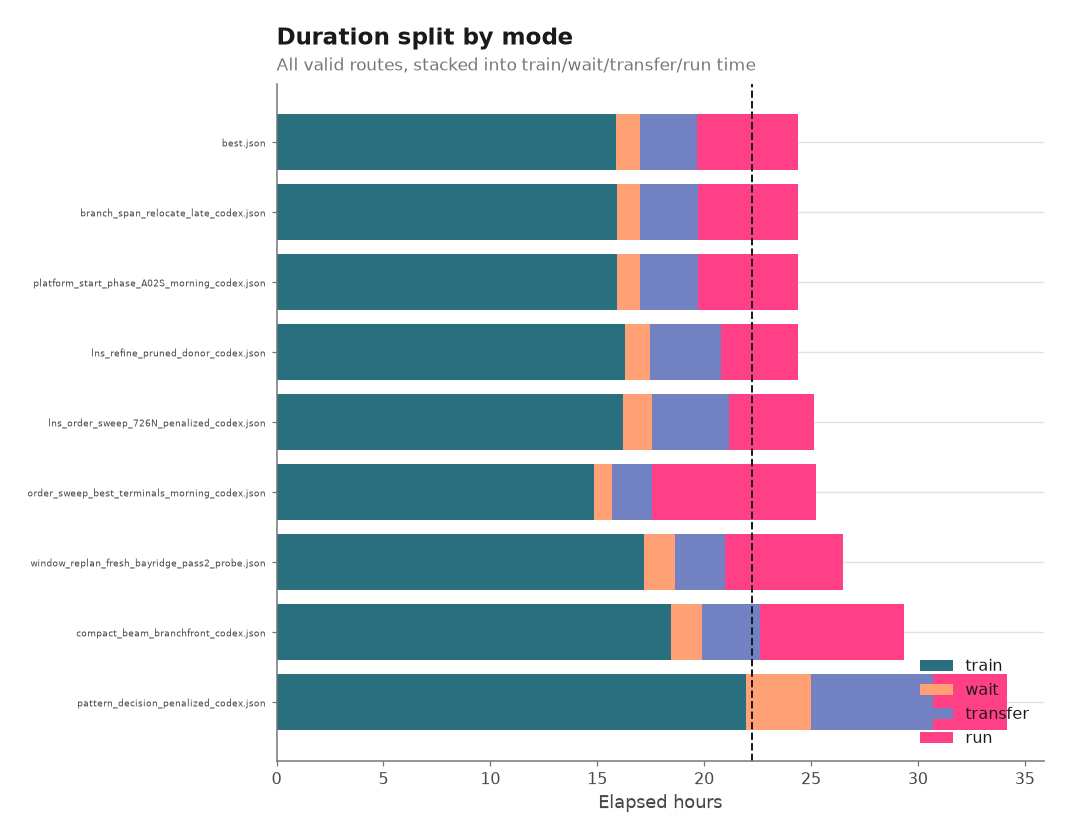

In [7]:
mode_routes = df_valid.copy().iloc[::-1]
fig_height = max(8, min(42, 0.105 * len(mode_routes)))
fig, ax = plt.subplots(figsize=(9, fig_height))
left = [0] * len(mode_routes)
mode_colors = {
    "train": blogstyle.TEAL,
    "wait": blogstyle.PEACH,
    "transfer": blogstyle.INDIGO,
    "run": blogstyle.MAGENTA,
}
for mode in ["train", "wait", "transfer", "run"]:
    vals = (mode_routes[f"{mode}_s"] / 3600).to_numpy()
    ax.barh(mode_routes["file"], vals, left=left, label=mode, color=mode_colors[mode])
    left = [a + b for a, b in zip(left, vals)]
ax.axvline(WORLD_RECORD_S / 3600, color=blogstyle.INK, linestyle="--", linewidth=1.3)
ax.tick_params(axis="y", labelsize=6)
ax.set_xlabel("Elapsed hours")
ax.legend(loc="lower right")
blogstyle.title(ax, "Duration split by mode", "All valid routes, stacked into train/wait/transfer/run time")
blogstyle.save(fig, "mode_breakdown", outdir=str(FIGURES))
plt.show()

,mode,mean_hours,median_hours
0,train,16.97,16.19
1,wait,1.39,1.18
2,transfer,3.07,2.73
3,run,5.01,4.67


  wrote /Users/fabianrigterink/Desktop/Code/subway-challenge/reports/route_summary/figures/mode_median_budget.png


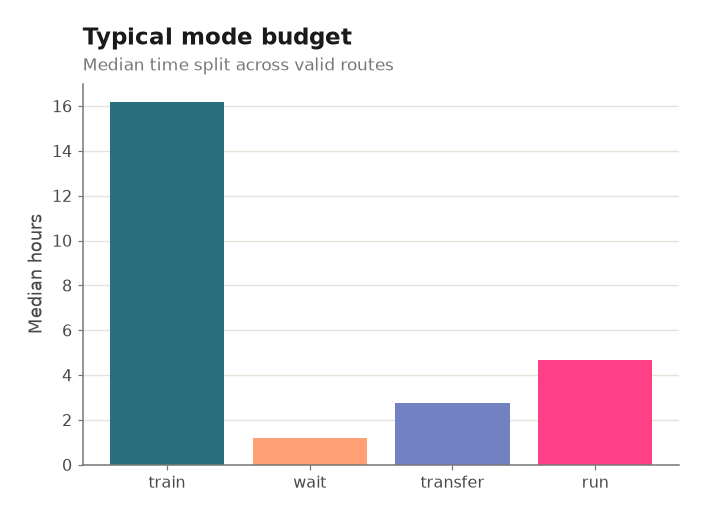

In [8]:
mode_totals = pd.DataFrame({
    "mode": ["train", "wait", "transfer", "run"],
    "mean_hours": [df_valid[f"{m}_h"].mean() for m in ["train", "wait", "transfer", "run"]],
    "median_hours": [df_valid[f"{m}_h"].median() for m in ["train", "wait", "transfer", "run"]],
})
mode_totals.to_csv(OUT / "mode_aggregate_summary.csv", index=False)
display(mode_totals.style.format({"mean_hours": "{:.2f}", "median_hours": "{:.2f}"}))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(mode_totals["mode"], mode_totals["median_hours"], color=[mode_colors[m] for m in mode_totals["mode"]])
ax.set_ylabel("Median hours")
blogstyle.title(ax, "Typical mode budget", "Median time split across valid routes")
blogstyle.save(fig, "mode_median_budget", outdir=str(FIGURES))
plt.show()

## 3. Most common start and end stations

In [9]:
def count_table(frame, col, top_n=None):
    out = (
        frame[col]
        .value_counts()
        .rename_axis(col)
        .reset_index(name="routes")
        .assign(pct=lambda x: x["routes"] / len(frame))
    )
    return out if top_n is None else out.head(top_n)

start_stations = count_table(df_valid, "start_station")
end_stations = count_table(df_valid, "end_station")
start_stations.to_csv(OUT / "common_start_stations.csv", index=False)
end_stations.to_csv(OUT / "common_end_stations.csv", index=False)

display(Markdown("### Starts"))
display(start_stations.style.format({"pct": "{:.1%}"}))
display(Markdown("### Ends"))
display(end_stations.style.format({"pct": "{:.1%}"}))

### Starts

,start_station,routes,pct
0,Inwood-207 St,5,55.6%
1,34 St-Hudson Yards,2,22.2%
2,Bay Ridge-95 St,1,11.1%
3,18 St,1,11.1%


### Ends

,end_station,routes,pct
0,110 St-Malcolm X Plaza,6,66.7%
1,Ozone Park-Lefferts Blvd,1,11.1%
2,Bowery,1,11.1%
3,Grand St,1,11.1%


  wrote /Users/fabianrigterink/Desktop/Code/subway-challenge/reports/route_summary/figures/common_endpoint_stations.png


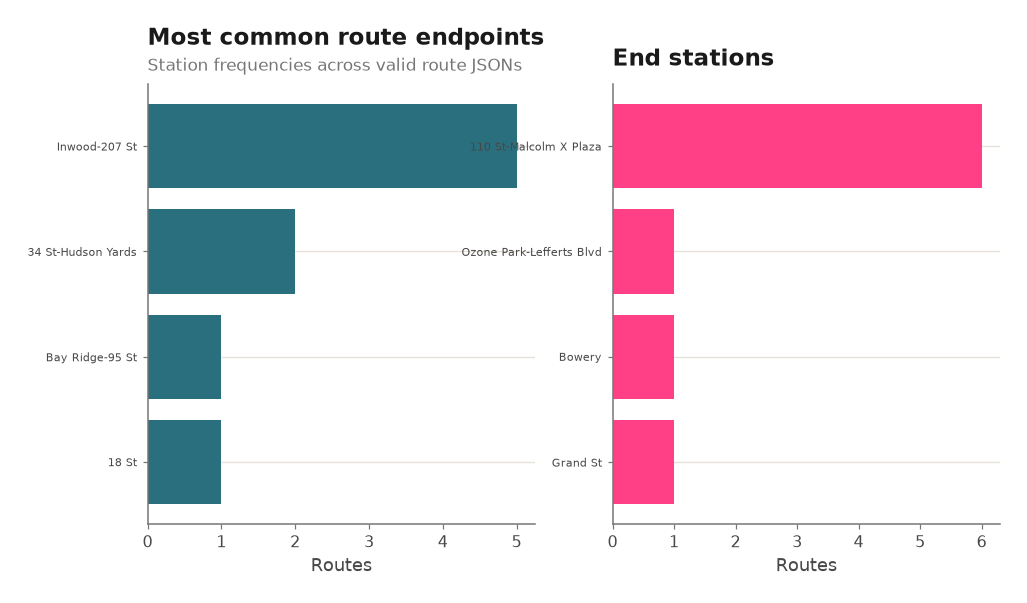

In [10]:
endpoint_height = max(5.2, min(24, 0.22 * max(len(start_stations), len(end_stations))))
fig, axes = plt.subplots(1, 2, figsize=(10, endpoint_height), sharex=False)
for ax, table, title, color in [
    (axes[0], start_stations.iloc[::-1], "Start stations", blogstyle.TEAL),
    (axes[1], end_stations.iloc[::-1], "End stations", blogstyle.MAGENTA),
]:
    station_col = table.columns[0]
    ax.barh(table[station_col], table["routes"], color=color)
    ax.tick_params(axis="y", labelsize=7)
    ax.set_xlabel("Routes")
    ax.set_title(title, loc="left")
blogstyle.title(axes[0], "Most common route endpoints", "Station frequencies across valid route JSONs")
blogstyle.save(fig, "common_endpoint_stations", outdir=str(FIGURES))
plt.show()

## 4. Most common start and end times

In [11]:
start_times = count_table(df_valid, "start_bucket_30m")
end_times = count_table(df_valid, "end_bucket_30m")
start_times.to_csv(OUT / "common_start_times_30m.csv", index=False)
end_times.to_csv(OUT / "common_end_times_30m.csv", index=False)

display(Markdown("### Starts, rounded to nearest 30 minutes"))
display(start_times.style.format({"pct": "{:.1%}"}))
display(Markdown("### Ends, rounded to nearest 30 minutes"))
display(end_times.style.format({"pct": "{:.1%}"}))

### Starts, rounded to nearest 30 minutes

,start_bucket_30m,routes,pct
0,06:00,5,55.6%
1,05:00,2,22.2%
2,05:30,2,22.2%


### Ends, rounded to nearest 30 minutes

,end_bucket_30m,routes,pct
0,06:30,6,66.7%
1,08:00,1,11.1%
2,11:30,1,11.1%
3,15:30,1,11.1%


  wrote /Users/fabianrigterink/Desktop/Code/subway-challenge/reports/route_summary/figures/endpoint_time_distributions.png


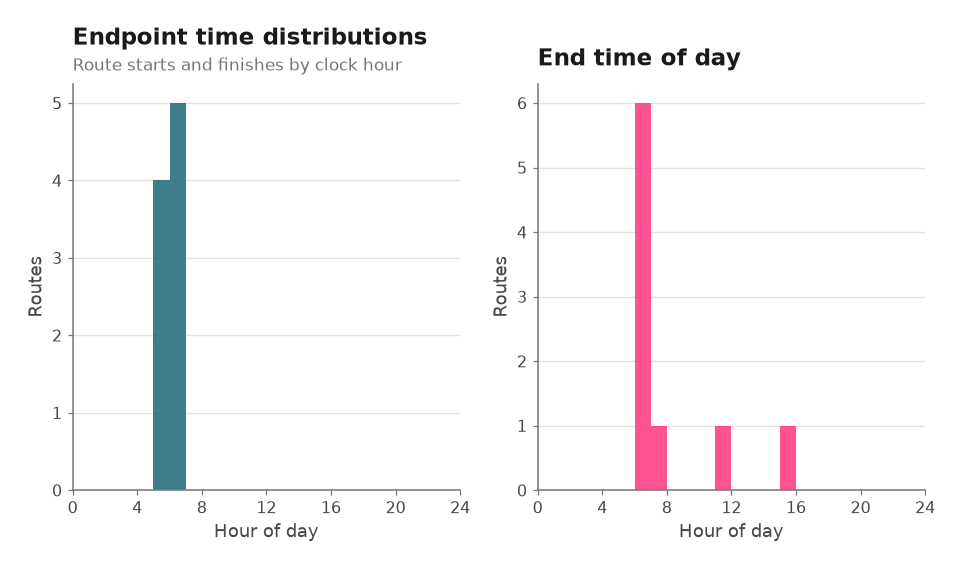

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))
for ax, col, title, color in [
    (axes[0], "start_hour", "Start time of day", blogstyle.TEAL),
    (axes[1], "end_hour", "End time of day", blogstyle.MAGENTA),
]:
    ax.hist(df_valid[col], bins=range(0, 25), color=color, alpha=0.9)
    ax.set_xlim(0, 24)
    ax.set_xticks(range(0, 25, 4))
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Routes")
    ax.set_title(title, loc="left")
blogstyle.title(axes[0], "Endpoint time distributions", "Route starts and finishes by clock hour")
blogstyle.save(fig, "endpoint_time_distributions", outdir=str(FIGURES))
plt.show()

## 5. Supporting route-pool statistics

In [13]:
family_summary = (
    df_valid.groupby("family")
    .agg(
        routes=("file", "count"),
        best_s=("elapsed_s", "min"),
        median_s=("elapsed_s", "median"),
        median_run_km=("run_km", "median"),
        median_steps=("steps", "median"),
    )
    .reset_index()
    .sort_values(["best_s", "routes"], ascending=[True, False])
)
family_summary["best"] = family_summary["best_s"].map(lambda x: hms(int(x)))
family_summary["median"] = family_summary["median_s"].map(lambda x: hms(int(x)))
family_summary.to_csv(OUT / "family_summary.csv", index=False)
display(family_summary[["family", "routes", "best", "median", "median_run_km", "median_steps"]].style.format({"median_run_km": "{:.1f}", "median_steps": "{:.0f}"}))

,family,routes,best,median,median_run_km,median_steps
0,LNS,2,24:24:30,24:46:00,30.0,670
1,branch,1,24:24:30,24:24:30,36.7,654
3,incumbent,1,24:24:30,24:24:30,38.1,652
6,platform,1,24:24:30,24:24:30,36.7,654
4,other,1,25:15:30,25:15:30,61.1,612
7,window,1,26:30:30,26:30:30,43.0,679
2,compact,1,29:20:00,29:20:00,57.0,711
5,pattern,1,34:11:00,34:11:00,28.0,872


  wrote /Users/fabianrigterink/Desktop/Code/subway-challenge/reports/route_summary/figures/elapsed_vs_running.png


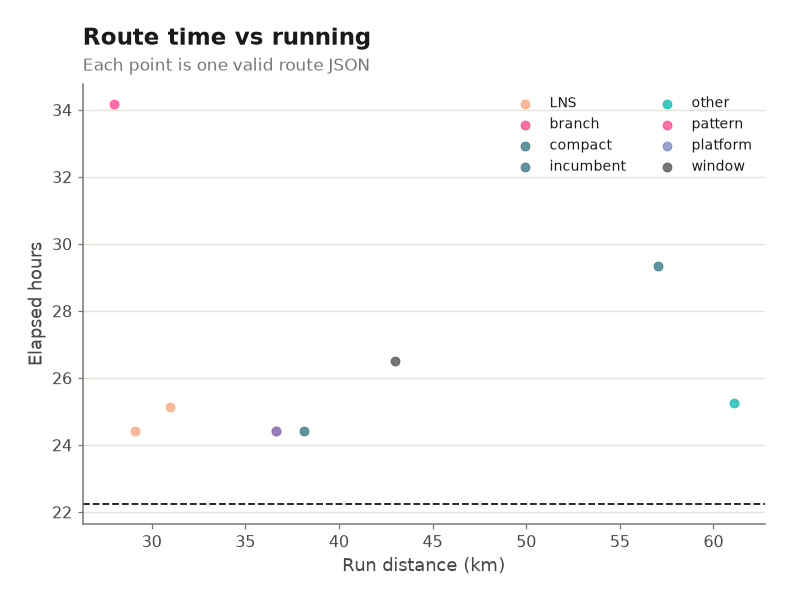

In [14]:
fig, ax = plt.subplots(figsize=(8, 5.2))
families = list(df_valid["family"].drop_duplicates())
palette = dict(zip(families, blogstyle.palette(len(families))))
for fam, group in df_valid.groupby("family"):
    ax.scatter(group["run_km"], group["elapsed_s"] / 3600, s=34, alpha=0.75, label=fam, color=palette[fam])
ax.axhline(WORLD_RECORD_S / 3600, color=blogstyle.INK, linestyle="--", linewidth=1.2)
ax.set_xlabel("Run distance (km)")
ax.set_ylabel("Elapsed hours")
ax.legend(ncol=2, fontsize=9)
blogstyle.title(ax, "Route time vs running", "Each point is one valid route JSON")
blogstyle.save(fig, "elapsed_vs_running", outdir=str(FIGURES))
plt.show()

,file,elapsed,cover_100,cover_250,cover_400,cover_425,cover_450,cover_472
0,best.json,24:24:30,04:09:00,10:37:30,20:12:00,22:08:00,23:15:00,24:24:30
1,branch_span_relocate_late_codex.json,24:24:30,04:09:00,10:37:30,20:12:00,22:08:00,23:15:00,24:24:30
2,platform_start_phase_A02S_morning_codex.json,24:24:30,04:09:00,10:37:30,20:12:00,22:08:00,23:15:00,24:24:30
3,lns_refine_pruned_donor_codex.json,24:24:30,04:09:00,10:37:30,20:12:00,22:08:00,23:13:30,24:24:30
4,lns_order_sweep_726N_penalized_codex.json,25:07:30,04:29:30,11:22:00,20:43:00,22:39:00,23:48:00,25:07:30
5,order_sweep_best_terminals_morning_codex.json,25:15:30,04:29:30,11:21:30,21:03:00,22:59:00,24:06:00,25:15:30
6,window_replan_fresh_bayridge_pass2_probe.json,26:30:30,03:22:30,09:37:30,18:20:00,21:43:00,23:36:30,26:30:30
7,compact_beam_branchfront_codex.json,29:20:00,04:33:30,13:44:30,23:08:30,24:55:30,26:56:30,29:20:00
8,pattern_decision_penalized_codex.json,34:11:00,04:51:00,13:15:30,25:04:30,26:27:30,31:53:00,34:11:00


  wrote /Users/fabianrigterink/Desktop/Code/subway-challenge/reports/route_summary/figures/milestones_vs_final_time.png


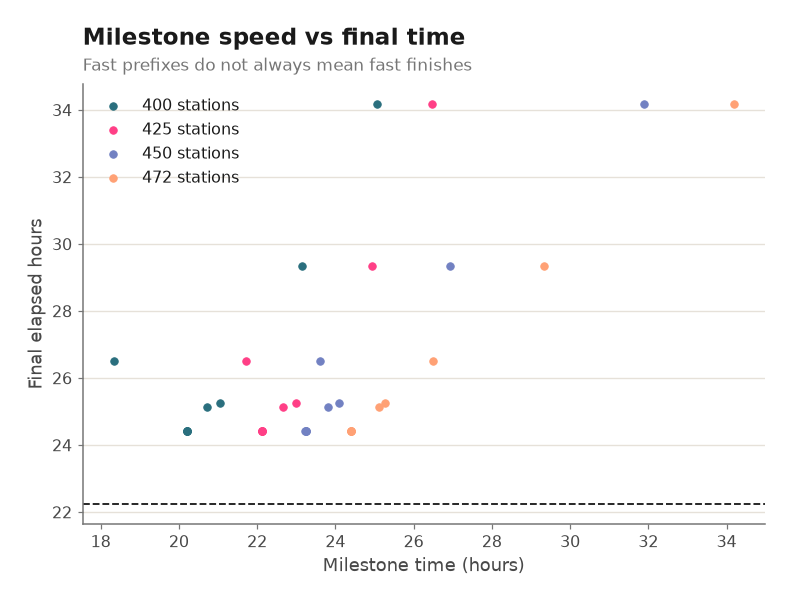

In [15]:
milestone_cols = ["file", "elapsed", *[f"cover_{m}" for m in MILESTONES]]
milestones = df_valid[milestone_cols].head(30).copy()
milestones.to_csv(OUT / "coverage_milestones_top30.csv", index=False)
display(milestones)

fig, ax = plt.subplots(figsize=(8, 5.2))
for m in [400, 425, 450, 472]:
    ax.scatter(df_valid[f"cover_{m}_s"] / 3600, df_valid["elapsed_s"] / 3600, s=24, label=f"{m} stations")
ax.axhline(WORLD_RECORD_S / 3600, color=blogstyle.INK, linestyle="--", linewidth=1.2)
ax.set_xlabel("Milestone time (hours)")
ax.set_ylabel("Final elapsed hours")
ax.legend()
blogstyle.title(ax, "Milestone speed vs final time", "Fast prefixes do not always mean fast finishes")
blogstyle.save(fig, "milestones_vs_final_time", outdir=str(FIGURES))
plt.show()

## Files written

In [16]:
for path in sorted(OUT.glob("**/*")):
    if path.is_file():
        print(path.relative_to(ROOT))

reports/route_summary/common_end_stations.csv
reports/route_summary/common_end_times_30m.csv
reports/route_summary/common_start_stations.csv
reports/route_summary/common_start_times_30m.csv
reports/route_summary/coverage_milestones_top30.csv
reports/route_summary/family_summary.csv
reports/route_summary/figures/common_endpoint_stations.png
reports/route_summary/figures/elapsed_vs_running.png
reports/route_summary/figures/endpoint_time_distributions.png
reports/route_summary/figures/milestones_vs_final_time.png
reports/route_summary/figures/mode_breakdown.png
reports/route_summary/figures/mode_median_budget.png
reports/route_summary/leaderboard.csv
reports/route_summary/leaderboard.md
reports/route_summary/mode_aggregate_summary.csv
reports/route_summary/mode_breakdown.csv
reports/route_summary/route_summary.csv
reports/route_summary/route_summary.json
